In [5]:
### Import des modules
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
data = pd.read_csv('data/rafined/employees.csv', sep=',')

In [6]:
# Plus un employé a d'ancienneté, moins il va avoir tendance à partir
data['ratio_anciennete_total_experence'] = np.where(
    data['annee_experience_totale'] > 0,
    data['annees_dans_l_entreprise'] / data['annee_experience_totale'],
    data['annees_dans_l_entreprise']
)

# Plus un employé évolue au sein de l'entreprise, moins il va avoir tendance à partir
data['ratio_poste_actuel_anciennete'] = np.where(
    data['annees_dans_l_entreprise'] > 0,
    data['annees_dans_le_poste_actuel'] / data['annees_dans_l_entreprise'],
    data['annees_dans_le_poste_actuel']
)

# Indicateur de pénibilité de déplacement distance * frequence (1=jamais, 1.5=occasionnel, 2=frequent)
data['score_penibilite_transport'] = data['distance_domicile_travail'] * data['frequence_deplacement']

# Plus le score bien-être est élevée moins un salarié va avoir tendance a quitter l'entreprise
colonnes_satisfaction = [
    'satisfaction_employee_environnement',
    'satisfaction_employee_nature_travail',
    'satisfaction_employee_equipe',
    'satisfaction_employee_equilibre_pro_perso'
]
data['score_bien_etre'] = data[colonnes_satisfaction].mean(axis=1)

# Plus le score de peformance est élevée plus un salarié va rester
colonnes_evaluation = [
    'note_evaluation_precedente',
    'note_evaluation_actuelle'
]

data['score_performance'] = data[colonnes_evaluation].mean(axis=1)

# Si l'évalusation est à la baisse, baisse des résultats donc salarié moins satisfait ?
data['evolution_performance'] = data['note_evaluation_actuelle'] - data['note_evaluation_precedente']

#
data['evolution_hierarchie_score'] = np.where(
    data['annee_experience_totale'] > 0,
    data['niveau_hierarchique_poste'] / data['annee_experience_totale'],
    data['niveau_hierarchique_poste']
)

# Plus un employé s'en va rapidement de ses anciennes entreprises, plus il aura tendance à partir rapidement ?
data['annee_par_experience'] = np.where(
    data['nombre_experiences_precedentes'] > 0,
    data['annee_experience_totale'] / data['nombre_experiences_precedentes'],
    data['annee_experience_totale']
)

# Création d'une colonne pour savoir comment se positione le salarié en salaire par rapport à ses collègues au même poste
data['quartile_salaire_par_poste'] = data.groupby('poste')['revenu_mensuel'].transform(
    lambda x: pd.qcut(x, q=4, labels=[1, 2, 3, 4], duplicates='drop')
)

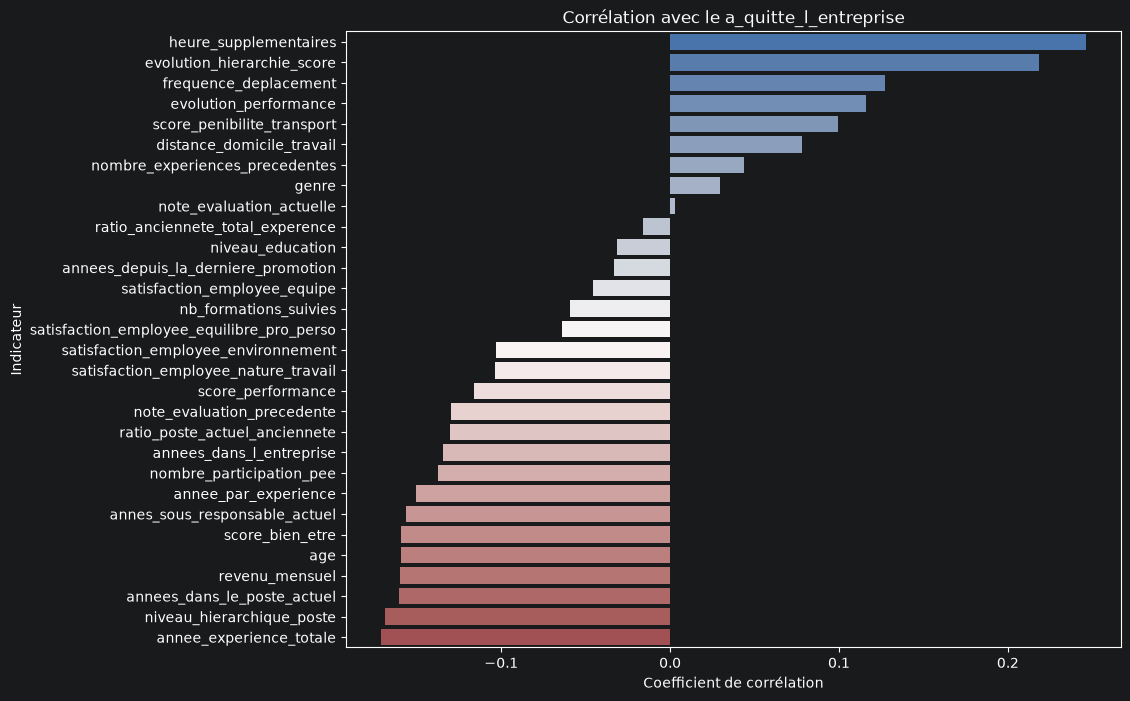

In [7]:
corr_matrix = data.select_dtypes(include=['float64', 'int64']).corr()

corr_avec_cible = corr_matrix['a_quitte_l_entreprise'].drop('a_quitte_l_entreprise').sort_values(ascending=False)

plt.figure(figsize=(10, 8))

sns.barplot(
    x=corr_avec_cible.values,
    y=corr_avec_cible.index,
    hue=corr_avec_cible.index,
    legend=False,
    palette='vlag'
)

plt.title("Corrélation avec le a_quitte_l_entreprise")
plt.xlabel("Coefficient de corrélation")
plt.ylabel("Indicateur")
plt.show()

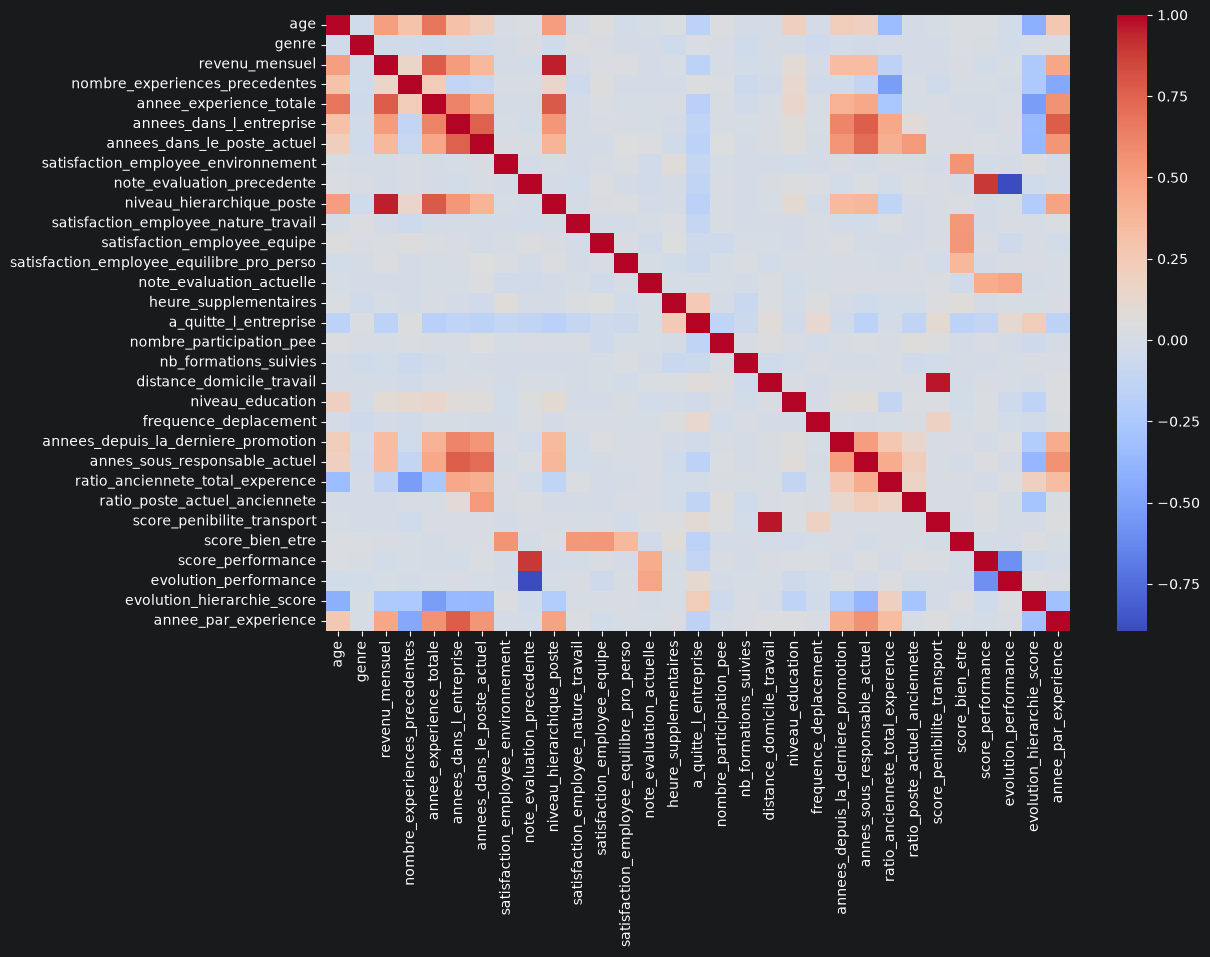

In [8]:
corr = data.select_dtypes(include=['float64', 'int64']).corr()

# 1. On agrandit la taille globale du graphique (largeur, hauteur)
plt.figure(figsize=(12, 8))

# 2. On trace la heatmap en forçant l'affichage de tous les labels
sns.heatmap(
    corr,
    xticklabels=True,
    yticklabels=True,
    cmap='coolwarm', # Petit bonus : une palette de couleurs sympa pour les corrélations
    annot=False      # Mets à True si tu veux afficher les valeurs chiffrées dans les cases
)

plt.show()

In [9]:
corr_cols_to_remove = [
    'note_evaluation_actuelle',
    'note_evaluation_precedente',
    'distance_domicile_travail',
    'frequence_deplacement',
]

data.drop(columns=[c for c in corr_cols_to_remove if c in data.columns], inplace=True)

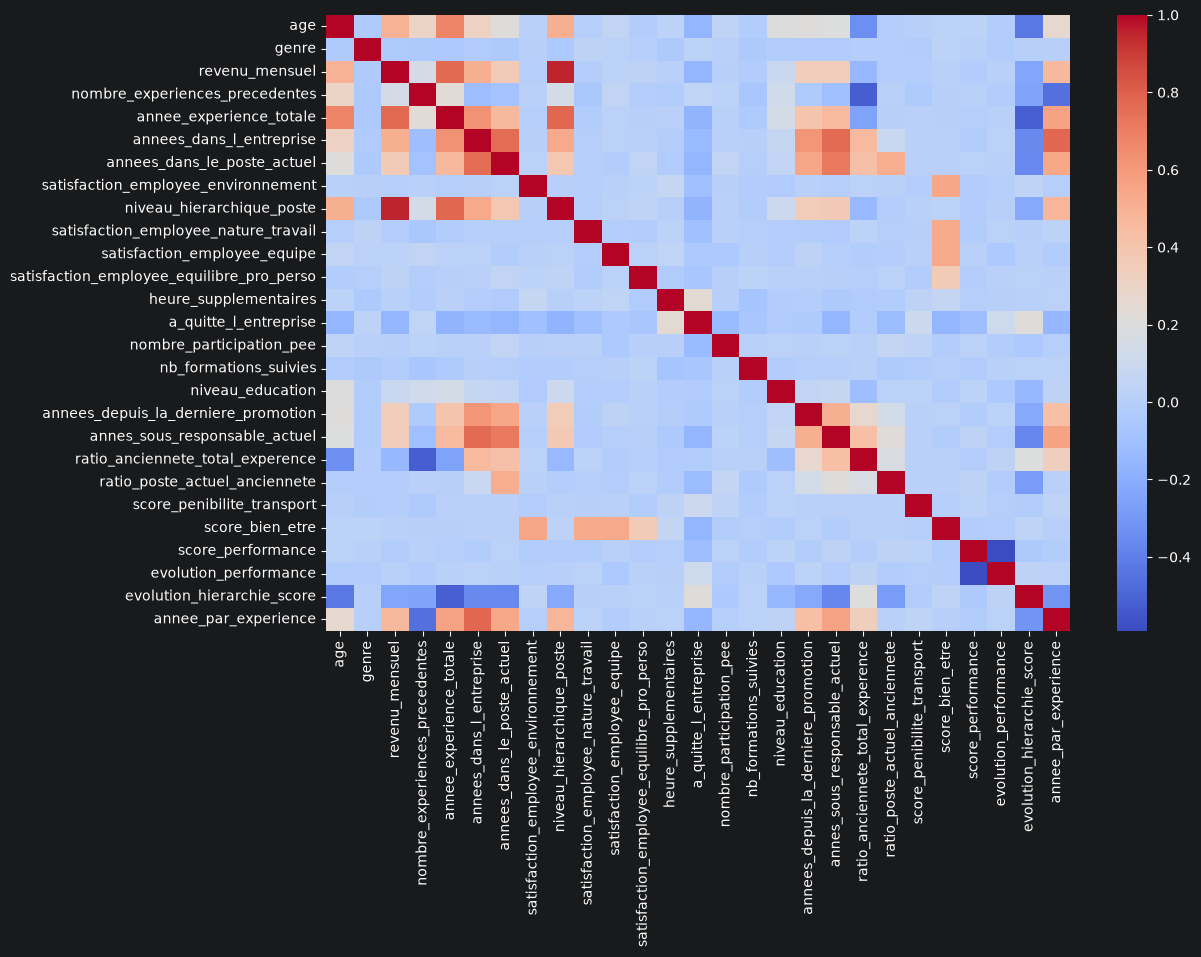

In [10]:
corr = data.select_dtypes(include=['float64', 'int64']).corr()

# 1. On agrandit la taille globale du graphique (largeur, hauteur)
plt.figure(figsize=(12, 8))

# 2. On trace la heatmap en forçant l'affichage de tous les labels
sns.heatmap(
    corr,
    xticklabels=True,
    yticklabels=True,
    cmap='coolwarm', # Petit bonus : une palette de couleurs sympa pour les corrélations
    annot=False      # Mets à True si tu veux afficher les valeurs chiffrées dans les cases
)

plt.show()